# Visuels à partir des fichiers logs checkpoints

Chargement des bibliothèques

In [159]:
import os
import re
import glob
import ast
import pandas as pd
import matplotlib.pyplot as plt

Chemin du dossier avec les logs (chemin local)

In [160]:
LOG_DIR = r"C:\Users\alexl\OneDrive\Bureau\SJTU\Computer Vision\Projet CV\CV-onceforall\runs\ofa_kernel_transform_10h\logs"

On commence par gérer tous les fichiers commençant par "eval"

In [161]:
log_files = glob.glob(os.path.join(LOG_DIR, "eval*"))

print(f"{len(log_files)} fichiers trouvés.\n")

for f in log_files:
    print(os.path.basename(f))

7 fichiers trouvés.

eval_120m.log
eval_160m.log
eval_25m.log
eval_30m.log
eval_40m.log
eval_60m.log
eval_80m.log


On réalise du parsing

In [162]:
results = []

for path in log_files:

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()

    data = {
        "file": os.path.basename(path),
    }

    macs_match = re.search(r"MACs:\s*([0-9.]+)M", text)

    if macs_match:
        data["MACs_M"] = float(macs_match.group(1))

    acc_match = re.search(r"Test accuracy:\s*([0-9.]+),\s*loss:\s*([0-9.]+)", text)

    if acc_match:
        data["accuracy"] = float(acc_match.group(1))
        data["loss"] = float(acc_match.group(2))

    time_match = re.search(r"Evaluation time:\s*total=([0-9.]+)s calib=([0-9.]+)s eval=([0-9.]+)s", text)

    if time_match:
        data["time_total"] = float(time_match.group(1))
        data["time_calib"] = float(time_match.group(2))
        data["time_eval"] = float(time_match.group(3))

    subnet_match = re.search(r"Subnet spec:\s*(\{.*\})", text)

    if subnet_match:

        try:
            subnet = eval(subnet_match.group(1))

            # Resolution
            data["resolution"] = subnet.get("r")

            # Kernel sizes
            ks = subnet.get("ks", [])
            data["avg_kernel"] = sum(ks) / len(ks) if ks else None
            data["max_kernel"] = max(ks) if ks else None
            data["min_kernel"] = min(ks) if ks else None

            # Expansion ratios
            e = subnet.get("e", [])
            data["avg_expand"] = sum(e) / len(e) if e else None
            data["max_expand"] = max(e) if e else None

            # Depth
            d = subnet.get("d", [])
            data["depth_total"] = sum(d) if d else None
            data["depth_max"] = max(d) if d else None

        except Exception as err:
            print(f"Erreur subnet spec dans {path}")
            print(err)

    results.append(data)

On crée un dataframe exploitable

In [163]:
df = pd.DataFrame(results)

# Tri par accuracy
df = df.sort_values("accuracy", ascending=False)

print("\nRésumé :")
print(df.head())


Résumé :
            file  MACs_M  accuracy    loss  time_total  time_calib  time_eval  \
0  eval_120m.log  118.39     94.19  0.1936        3.59        2.58       1.01   
1  eval_160m.log  133.31     94.17  0.1911        3.80        2.68       1.13   
6   eval_80m.log   76.97     93.46  0.2115        2.79        2.14       0.64   
5   eval_60m.log   59.58     93.17  0.2270        2.50        1.99       0.52   
4   eval_40m.log   39.62     91.52  0.3117        2.24        1.85       0.39   

   resolution  avg_kernel  max_kernel  min_kernel  avg_expand  max_expand  \
0          32         6.0           7           3        4.75           6   
1          32         5.6           7           3        5.05           6   
6          32         4.7           7           3        4.15           6   
5          32         5.3           7           3        4.15           6   
4          24         4.6           7           3        4.75           6   

   depth_total  depth_max  
0           

# Visualisations

# Accuracy vs MACs

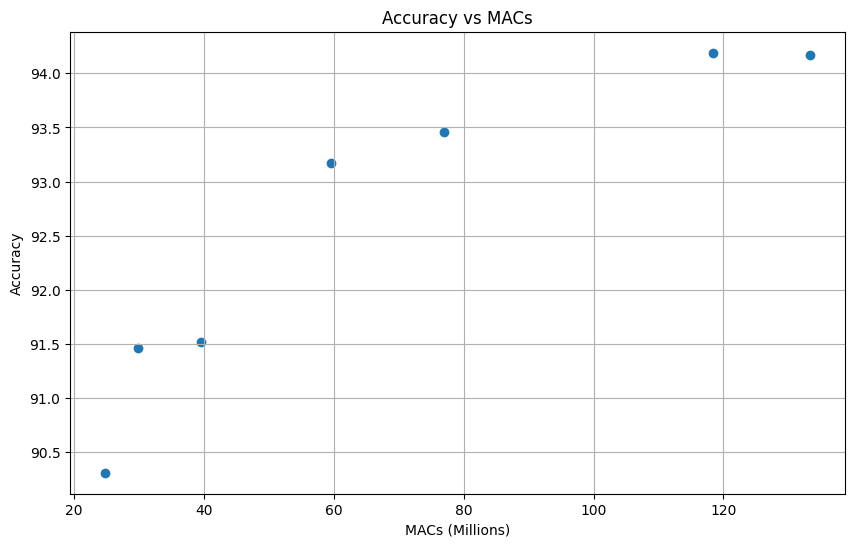

In [164]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df["MACs_M"],
    df["accuracy"]
)
plt.xlabel("MACs (Millions)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs MACs")
plt.grid()
plt.show()


Accuracy vs Evaluation Time

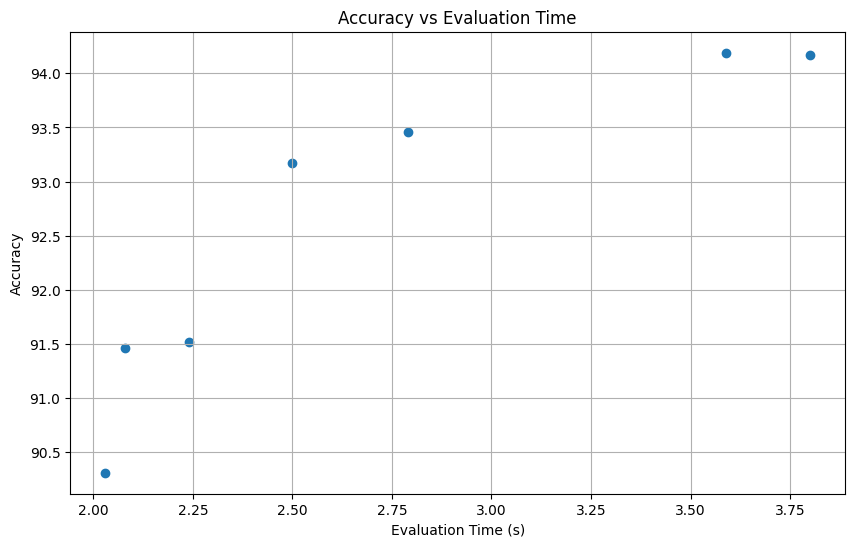

In [165]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df["time_total"],
    df["accuracy"]
)
plt.xlabel("Evaluation Time (s)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Evaluation Time")
plt.grid()
plt.show()

Accuracy vs Average Kernel Size

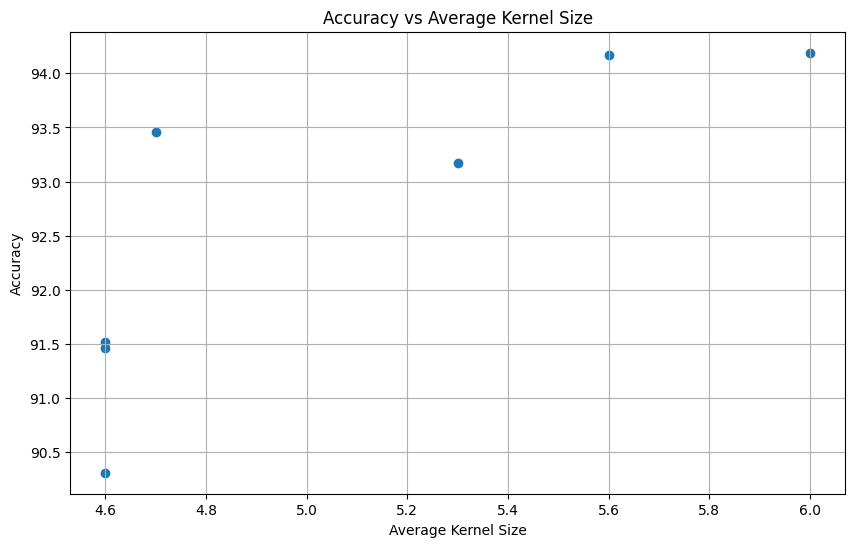

In [166]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df["avg_kernel"],
    df["accuracy"]
)
plt.xlabel("Average Kernel Size")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Average Kernel Size")
plt.grid()
plt.show()

Accuracy vs Expansion Ratio

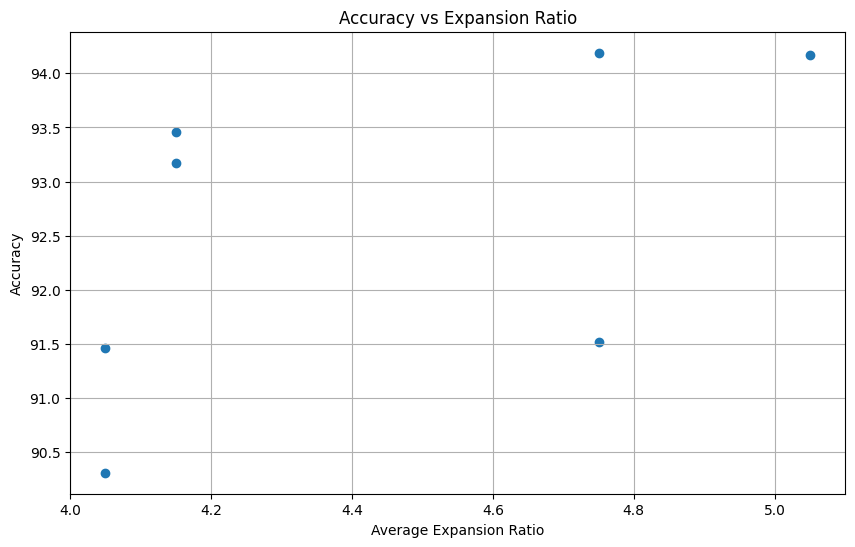

In [167]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df["avg_expand"],
    df["accuracy"]
)
plt.xlabel("Average Expansion Ratio")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Expansion Ratio")
plt.grid()
plt.show()

Accuracy vs Total Depth

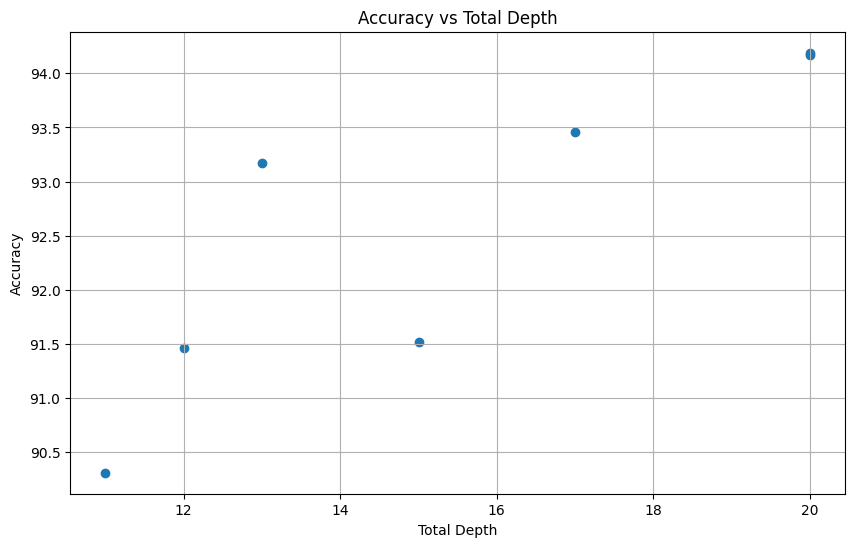

In [168]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df["depth_total"],
    df["accuracy"]
)
plt.xlabel("Total Depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Total Depth")
plt.grid()
plt.show()

# TOP MODELS

In [169]:
print("\nTOP 15 MODELS\n")

top = df.head(15)

print(
    top[
        [
            "accuracy",
            "loss",
            "MACs_M",
            "time_total",
            "resolution",
            "avg_kernel",
            "avg_expand",
            "depth_total"
        ]
    ]
)


TOP 15 MODELS

   accuracy    loss  MACs_M  time_total  resolution  avg_kernel  avg_expand  \
0     94.19  0.1936  118.39        3.59          32         6.0        4.75   
1     94.17  0.1911  133.31        3.80          32         5.6        5.05   
6     93.46  0.2115   76.97        2.79          32         4.7        4.15   
5     93.17  0.2270   59.58        2.50          32         5.3        4.15   
4     91.52  0.3117   39.62        2.24          24         4.6        4.75   
3     91.46  0.3238   29.89        2.08          24         4.6        4.05   
2     90.31  0.3613   24.82        2.03          24         4.6        4.05   

   depth_total  
0           20  
1           20  
6           17  
5           13  
4           15  
3           12  
2           11  


# Avec les fichiers commençant par search

In [170]:
search_files = sorted(glob.glob(os.path.join(LOG_DIR, "search*")))
search_files = [f for f in search_files if os.path.isfile(f)]

print(f"{len(search_files)} fichiers trouvés")

9 fichiers trouvés


On parse les fichiers

In [171]:
rows = []

for path in search_files:

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()

    row = {"file": os.path.basename(path)}

    m = re.findall(r"gen=(\d+)", text)
    if m:
        row["n_gen"] = len(m)
        row["last_gen"] = int(m[-1])

    accs = re.findall(r"best_pred_acc=([0-9.]+)", text)
    if accs:
        row["best_pred_acc"] = float(accs[-1])

    macs = re.findall(r"best_macs=([0-9.]+)M", text)
    if macs:
        row["best_macs_M"] = float(macs[-1])

    spec_match = re.findall(r"spec=({.*?})", text)

    if spec_match:
        try:
            spec = ast.literal_eval(spec_match[-1])

            row["r"] = spec.get("r")

            ks = spec.get("ks", [])
            e = spec.get("e", [])
            d = spec.get("d", [])

            row["avg_kernel"] = sum(ks) / len(ks) if ks else None
            row["avg_expand"] = sum(e) / len(e) if e else None
            row["depth"] = sum(d) if d else None

            row["max_kernel"] = max(ks) if ks else None
            row["min_kernel"] = min(ks) if ks else None

        except Exception as err:
            print(f"Erreur spec: {path}")
            print(err)

    rows.append(row)

On crée un dataframe clean

In [172]:
df = pd.DataFrame(rows)
df = df.sort_values("best_pred_acc", ascending=False)

print("\nAperçu :")
print(df.head())


Aperçu :
              file  n_gen  last_gen  best_pred_acc  best_macs_M     r  \
1  search_160m.log  200.0     199.0         95.878       133.31  32.0   
0  search_120m.log  200.0     199.0         95.785       118.39  32.0   
7   search_80m.log  200.0     199.0         95.300        76.97  32.0   
6   search_60m.log  200.0     199.0         94.645        59.58  32.0   
5   search_40m.log  200.0     199.0         93.376        39.62  24.0   

   avg_kernel  avg_expand  depth  max_kernel  min_kernel  
1         5.6        5.05   20.0         7.0         3.0  
0         6.0        4.75   20.0         7.0         3.0  
7         4.7        4.15   17.0         7.0         3.0  
6         5.3        4.15   13.0         7.0         3.0  
5         4.6        4.75   15.0         7.0         3.0  


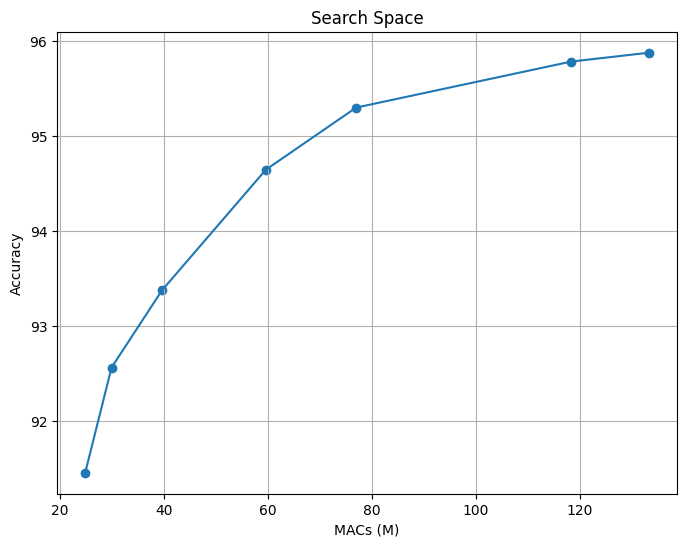

In [173]:
plt.figure(figsize=(8,6))
plt.scatter(df["best_macs_M"], df["best_pred_acc"])

df_sorted = df.sort_values("best_macs_M")

x, y = [], []
best = -1

for _, row in df_sorted.iterrows():
    if row["best_pred_acc"] > best:
        x.append(row["best_macs_M"])
        y.append(row["best_pred_acc"])
        best = row["best_pred_acc"]

plt.plot(x, y)
plt.xlabel("MACs (M)")
plt.ylabel("Accuracy")
plt.title("Search Space")
plt.grid()
plt.show()

Scaling law implicite (accuracy vs compute)

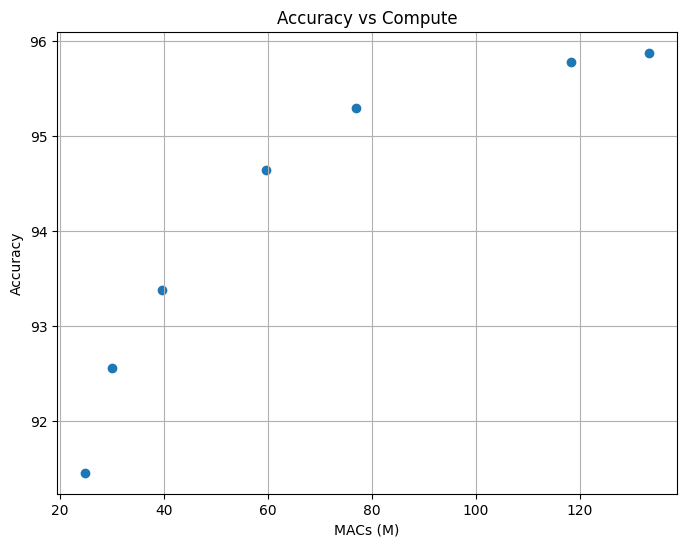

In [174]:
plt.figure(figsize=(8,6))
plt.scatter(df["best_macs_M"], df["best_pred_acc"])
plt.xlabel("MACs (M)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Compute")
plt.grid()
plt.show()

Influence architecture (kernel size)

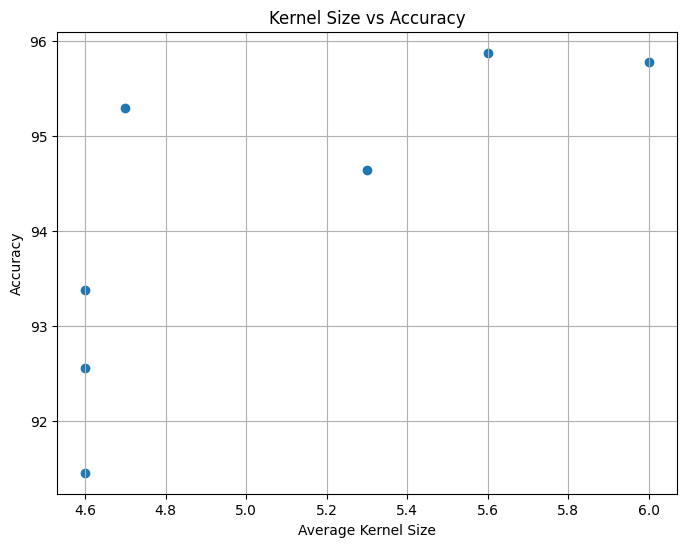

In [175]:
plt.figure(figsize=(8,6))
plt.scatter(df["avg_kernel"], df["best_pred_acc"])
plt.xlabel("Average Kernel Size")
plt.ylabel("Accuracy")
plt.title("Kernel Size vs Accuracy")
plt.grid()
plt.show()

Expansion ratio vs performance

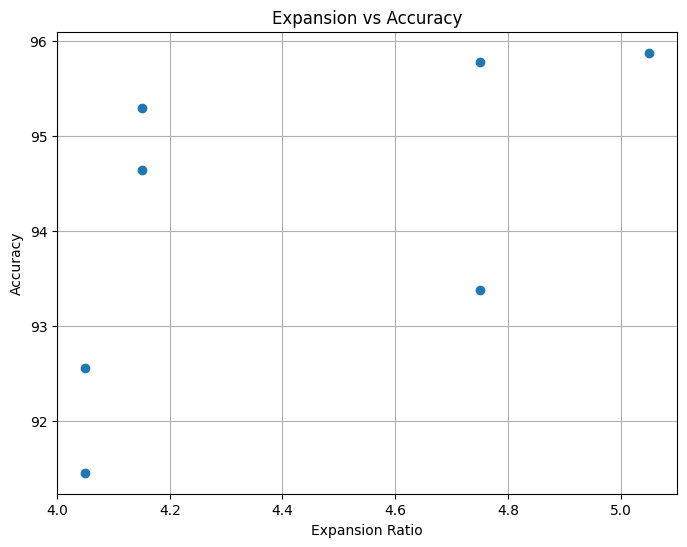

In [176]:
plt.figure(figsize=(8,6))
plt.scatter(df["avg_expand"], df["best_pred_acc"])
plt.xlabel("Expansion Ratio")
plt.ylabel("Accuracy")
plt.title("Expansion vs Accuracy")
plt.grid()
plt.show()

Depth vs performance

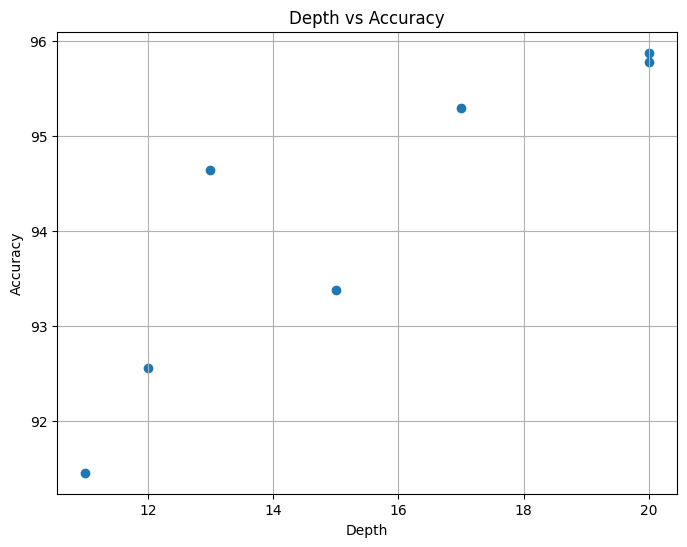

In [177]:
plt.figure(figsize=(8,6))
plt.scatter(df["depth"], df["best_pred_acc"])
plt.xlabel("Depth")
plt.ylabel("Accuracy")
plt.title("Depth vs Accuracy")
plt.grid()
plt.show()